In [1]:
import os
import json
import numpy as np
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

PHASE3_DATA = Path("Phase3_Data")

DIRS = {
    "baseline_imgs" : PHASE3_DATA / "generated" / "baseline",
    "exp_imgs"      : PHASE3_DATA / "generated" / "experimental",
    "trajectories"  : PHASE3_DATA / "trajectories",
    "annotations"   : PHASE3_DATA / "annotations",
    "figures"       : PHASE3_DATA / "figures",
}

YOLO_WEIGHTS = Path("yolov8x.pt")

PHASE4_OUT = Path("Phase4_Results")
PHASE4_OUT.mkdir(exist_ok=True)

print("PATH VERIFICATION")

all_ok = True
for name, path in DIRS.items():
    exists = path.exists()
    status = "ok" if exists else "MISSING"
    print(f"  {name:<20} {status}")
    if not exists:
        all_ok = False

yolo_ok = YOLO_WEIGHTS.exists()
print(f"  {'yolov8x.pt':<20} {'ok' if yolo_ok else 'MISSING'}")
if not yolo_ok:
    all_ok = False

print(f"  {'Phase4_Results':<20} ok (created)")
print()

if not all_ok:
    raise FileNotFoundError("One or more paths are missing. Check above.")

with open(DIRS["annotations"] / "baseline_metadata.json") as f:
    baseline_meta = json.load(f)

with open(DIRS["annotations"] / "experimental_metadata.json") as f:
    exp_meta = json.load(f)

print("METADATA LOADED")
print("=" * 55)
print(f"  Baseline records    : {len(baseline_meta)}")
print(f"  Experimental records: {len(exp_meta)}")
print()

print("Sample baseline record:")
print(json.dumps(baseline_meta[0], indent=4))
print()
print("Sample experimental record:")
print(json.dumps(exp_meta[0], indent=4))
print()

n_baseline_imgs = len(list(DIRS["baseline_imgs"].glob("*.png")))
n_exp_imgs      = len(list(DIRS["exp_imgs"].glob("*.png")))
n_traj_files    = len(list(DIRS["trajectories"].glob("*.npy")))

print("FILE COUNTS")

print(f"  Baseline PNGs     : {n_baseline_imgs}  (expected 1000)")
print(f"  Experimental PNGs : {n_exp_imgs}  (expected 7000)")
print(f"  Trajectory .npy   : {n_traj_files}  (expected 8000)")
print()

print("EXPERIMENTAL — DISTRIBUTION CHECK")

cfg_counts      = Counter(r["cfg"] for r in exp_meta)
category_counts = Counter(r["category"] for r in exp_meta)

print("  CFG values:")
for cfg in sorted(cfg_counts.keys()):
    print(f"    CFG={cfg:<5}  →  {cfg_counts[cfg]} images")

print()
print("  Categories:")
for cat in sorted(category_counts.keys()):
    print(f"    {cat:<20}  →  {category_counts[cat]} images")

variances = np.array([r["variance"] for r in exp_meta])
print()
print("=" * 55)
print("VARIANCE SANITY CHECK")
print("=" * 55)
print(f"  Count     : {len(variances)}")
print(f"  Min       : {variances.min():.6f}")
print(f"  Max       : {variances.max():.6f}")
print(f"  Mean      : {variances.mean():.6f}")
print(f"  Std       : {variances.std():.6f}")
near_zero = (variances < 1e-5).sum()
print(f"  Near-zero : {near_zero}  {'healthy' if near_zero == 0 else 'check!'}")

print()

if all_ok and len(baseline_meta) == 1000 and len(exp_meta) == 7000:
    print("SECTION 1 COMPLETE — Ready for Section 2.")
else:
    print("Something looks off — check counts above.")

PATH VERIFICATION
  baseline_imgs        ok
  exp_imgs             ok
  trajectories         ok
  annotations          ok
  figures              ok
  yolov8x.pt           ok
  Phase4_Results       ok (created)

METADATA LOADED
  Baseline records    : 1000
  Experimental records: 7000

Sample baseline record:
{
    "key": "baseline__SC1__s050__cfg7.5",
    "split": "baseline",
    "prompt_id": "SC1",
    "category": "Single-Concept",
    "prompt": "A single red apple",
    "seed": 50,
    "cfg": 7.5,
    "variance": 0.002126611303538084
}

Sample experimental record:
{
    "key": "experimental__SC1__s000__cfg0.0",
    "split": "experimental",
    "prompt_id": "SC1",
    "category": "Single-Concept",
    "prompt": "A single red apple",
    "seed": 0,
    "cfg": 0,
    "variance": 0.003340875031426549
}

FILE COUNTS
  Baseline PNGs     : 1000  (expected 1000)
  Experimental PNGs : 7000  (expected 7000)
  Trajectory .npy   : 8000  (expected 8000)

EXPERIMENTAL — DISTRIBUTION CHECK
  CFG va

In [4]:
import torch
import open_clip
from PIL import Image
from tqdm import tqdm
import copy

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLIP_BATCH_SIZE = 32

print("SECTION 2 — CLIP SCORING (BASELINE)")
print(f"Device: {DEVICE}")
print("Loading CLIP ViT-L/14 ...")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="openai"
)
clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer("ViT-L-14")

print("CLIP loaded\n")

def key_to_filename(key):
    return key + ".png"

test_key  = baseline_meta[0]["key"]
test_file = key_to_filename(test_key)
test_path = DIRS["baseline_imgs"] / test_file
print(f"Filename check:")
print(f"  key  → {test_key}")
print(f"  file → {test_file}")
print(f"  exists: {'ok' if test_path.exists() else 'NOT FOUND — stop and check'}")
print()

if not test_path.exists():
    raise FileNotFoundError(
        f"Could not find image: {test_path}\n"
        f"Check if the filename format differs from key_to_filename() above."
    )

@torch.no_grad()
def compute_clip_scores(records, img_dir, batch_size=32):
    scores = []
    n = len(records)

    for start in tqdm(range(0, n, batch_size), desc="CLIP scoring"):
        batch = records[start : start + batch_size]

        images = []
        for r in batch:
            img_path = img_dir / key_to_filename(r["key"])
            img = clip_preprocess(Image.open(img_path).convert("RGB"))
            images.append(img)

        img_tensor = torch.stack(images).to(DEVICE)  

        prompts     = [r["prompt"] for r in batch]
        text_tokens = clip_tokenizer(prompts).to(DEVICE)

        img_feats  = clip_model.encode_image(img_tensor)
        text_feats = clip_model.encode_text(text_tokens)

        img_feats  = img_feats  / img_feats.norm(dim=-1, keepdim=True)
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

        batch_scores = (img_feats * text_feats).sum(dim=-1).cpu().float().tolist()
        scores.extend(batch_scores)

    return scores

print("Scoring 1,000 baseline images ...")
baseline_scores = compute_clip_scores(
    baseline_meta,
    DIRS["baseline_imgs"],
    batch_size=CLIP_BATCH_SIZE
)

baseline_with_clip = copy.deepcopy(baseline_meta)
for record, score in zip(baseline_with_clip, baseline_scores):
    record["clip_score"] = round(score, 6)

out_path = PHASE4_OUT / "baseline_with_clip.json"
with open(out_path, "w") as f:
    json.dump(baseline_with_clip, f, indent=2)

print(f"\nSaved: {out_path}")

all_scores = np.array(baseline_scores)
print()
print("BASELINE CLIP SCORE STATS")
print(f"  Count  : {len(all_scores)}")
print(f"  Min    : {all_scores.min():.4f}")
print(f"  Max    : {all_scores.max():.4f}")
print(f"  Mean   : {all_scores.mean():.4f}")
print(f"  Std    : {all_scores.std():.4f}")
print()

print("Per-category CLIP scores:")
cat_scores = {}
for r in baseline_with_clip:
    cat_scores.setdefault(r["category"], []).append(r["clip_score"])

for cat in sorted(cat_scores.keys()):
    s = np.array(cat_scores[cat])
    print(f"  {cat:<20}  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}")

print()
print("Sample records with clip_score:")
for r in baseline_with_clip[:3]:
    print(f"  {r['key']:<40}  clip={r['clip_score']:.4f}  var={r['variance']:.6f}")

print()
print("SECTION 2 COMPLETE — Ready for Section 3.")

SECTION 2 — CLIP SCORING (BASELINE)
Device: cuda
Loading CLIP ViT-L/14 ...
CLIP loaded

Filename check:
  key  → baseline__SC1__s050__cfg7.5
  file → baseline__SC1__s050__cfg7.5.png
  exists: ok

Scoring 1,000 baseline images ...


CLIP scoring: 100%|██████████| 32/32 [00:58<00:00,  1.83s/it]


Saved: Phase4_Results\baseline_with_clip.json

BASELINE CLIP SCORE STATS
  Count  : 1000
  Min    : 0.1711
  Max    : 0.3128
  Mean   : 0.2364
  Std    : 0.0260

Per-category CLIP scores:
  Ambiguous             mean=0.2108  std=0.0121  min=0.1719  max=0.2447
  Compositional         mean=0.2509  std=0.0223  min=0.2006  max=0.3128
  Conflicting           mean=0.2369  std=0.0292  min=0.1711  max=0.2995
  Negation              mean=0.2248  std=0.0120  min=0.1910  max=0.2556
  Single-Concept        mean=0.2589  std=0.0153  min=0.2271  max=0.3005

Sample records with clip_score:
  baseline__SC1__s050__cfg7.5               clip=0.2692  var=0.002127
  baseline__SC1__s051__cfg7.5               clip=0.2480  var=0.001890
  baseline__SC1__s052__cfg7.5               clip=0.2425  var=0.003003

SECTION 2 COMPLETE — Ready for Section 3.


In [ ]:
print("SECTION 3 — CALIBRATION THRESHOLDS")

from collections import defaultdict

category_data = defaultdict(lambda: {"variance": [], "clip_score": []})

for r in baseline_with_clip:
    cat = r["category"]
    category_data[cat]["variance"].append(r["variance"])
    category_data[cat]["clip_score"].append(r["clip_score"])

thresholds = {}

print(f"\n{'Category':<20} {'n':>4}  {'μ_var':>8} {'σ_var':>8} {'T_var':>8}  "
      f"{'μ_clip':>7} {'σ_clip':>7} {'T_clip':>7}")
print("-" * 80)

for cat in sorted(category_data.keys()):
    variances_cat   = np.array(category_data[cat]["variance"])
    clip_scores_cat = np.array(category_data[cat]["clip_score"])

    mu_var    = variances_cat.mean()
    std_var   = variances_cat.std()
    T_var     = mu_var + 2 * std_var     

    mu_clip   = clip_scores_cat.mean()
    std_clip  = clip_scores_cat.std()
    T_clip    = mu_clip - 2 * std_clip    

    thresholds[cat] = {
        "n"        : len(variances_cat),
        "mu_var"   : round(float(mu_var),   8),
        "std_var"  : round(float(std_var),  8),
        "T_var"    : round(float(T_var),    8),
        "mu_clip"  : round(float(mu_clip),  6),
        "std_clip" : round(float(std_clip), 6),
        "T_clip"   : round(float(T_clip),   6),
    }

    print(f"  {cat:<20} {len(variances_cat):>4}  "
          f"{mu_var:>8.6f} {std_var:>8.6f} {T_var:>8.6f}  "
          f"{mu_clip:>7.4f} {std_clip:>7.4f} {T_clip:>7.4f}")

all_vars   = np.array([r["variance"]   for r in baseline_with_clip])
all_clips  = np.array([r["clip_score"] for r in baseline_with_clip])

global_T_var  = all_vars.mean()  + 2 * all_vars.std()
global_T_clip = all_clips.mean() - 2 * all_clips.std()

thresholds["__global__"] = {
    "n"        : len(all_vars),
    "mu_var"   : round(float(all_vars.mean()),   8),
    "std_var"  : round(float(all_vars.std()),    8),
    "T_var"    : round(float(global_T_var),      8),
    "mu_clip"  : round(float(all_clips.mean()),  6),
    "std_clip" : round(float(all_clips.std()),   6),
    "T_clip"   : round(float(global_T_clip),     6),
}

print("-" * 80)
print(f"  {'GLOBAL (fallback)':<20} {len(all_vars):>4}  "
      f"{all_vars.mean():>8.6f} {all_vars.std():>8.6f} {global_T_var:>8.6f}  "
      f"{all_clips.mean():>7.4f} {all_clips.std():>7.4f} {global_T_clip:>7.4f}")

thresh_path = PHASE4_OUT / "thresholds.json"
with open(thresh_path, "w") as f:
    json.dump(thresholds, f, indent=2)

print(f"\nSaved: {thresh_path}")

print()
print("THRESHOLD INTERPRETATION")
print("An experimental image is flagged as:")
print("  HIGH VARIANCE  if  variance   > T_var  (geometrically unstable)")
print("  LOW CLIP       if  clip_score < T_clip (semantically misaligned)")
print()
for cat in sorted(thresholds.keys()):
    if cat == "__global__":
        continue
    t = thresholds[cat]
    print(f"  {cat:<20}  var > {t['T_var']:.6f}  |  clip < {t['T_clip']:.4f}")

print()
print("SECTION 3 COMPLETE — Ready for Section 4.")

SECTION 3 — CALIBRATION THRESHOLDS

Category                n     μ_var    σ_var    T_var   μ_clip  σ_clip  T_clip
--------------------------------------------------------------------------------
  Ambiguous             200  0.003002 0.001254 0.005510   0.2108  0.0121  0.1865
  Compositional         200  0.002490 0.000510 0.003509   0.2509  0.0223  0.2063
  Conflicting           200  0.003048 0.001363 0.005774   0.2369  0.0292  0.1785
  Negation              200  0.002868 0.000459 0.003787   0.2248  0.0120  0.2008
  Single-Concept        200  0.002352 0.000520 0.003393   0.2589  0.0153  0.2282
--------------------------------------------------------------------------------
  GLOBAL (fallback)    1000  0.002752 0.000955 0.004663   0.2364  0.0260  0.1844

✅ Saved: Phase4_Results\thresholds.json

THRESHOLD INTERPRETATION
An experimental image is flagged as:
  HIGH VARIANCE  if  variance   > T_var  (geometrically unstable)
  LOW CLIP       if  clip_score < T_clip (semantically misaligned)


In [6]:
import copy

print("=" * 55)
print("SECTION 4 — CLIP SCORING (EXPERIMENTAL)")
print("=" * 55)
print(f"Images to score : {len(exp_meta)}")
print(f"Batch size      : {CLIP_BATCH_SIZE}")
print(f"Device          : {DEVICE}")
print()

test_key  = exp_meta[0]["key"]
test_file = key_to_filename(test_key)
test_path = DIRS["exp_imgs"] / test_file

print(f"Filename check:")
print(f"  key  → {test_key}")
print(f"  file → {test_file}")
print(f"  exists: {'ok' if test_path.exists() else ' NOT FOUND — stop and check'}")
print()

if not test_path.exists():
    raise FileNotFoundError(f"Could not find: {test_path}")

print("Scoring 7,000 experimental images ...")
print("(This will take ~30-35 minutes — progress bar below)\n")

exp_scores = compute_clip_scores(
    exp_meta,
    DIRS["exp_imgs"],
    batch_size=CLIP_BATCH_SIZE
)

exp_with_clip = copy.deepcopy(exp_meta)
for record, score in zip(exp_with_clip, exp_scores):
    record["clip_score"] = round(score, 6)

out_path = PHASE4_OUT / "experimental_with_clip.json"
with open(out_path, "w") as f:
    json.dump(exp_with_clip, f, indent=2)

print(f"\n✅ Saved: {out_path}")

all_scores = np.array(exp_scores)
print()
print("EXPERIMENTAL CLIP SCORE STATS")
print(f"  Count  : {len(all_scores)}")
print(f"  Min    : {all_scores.min():.4f}")
print(f"  Max    : {all_scores.max():.4f}")
print(f"  Mean   : {all_scores.mean():.4f}")
print(f"  Std    : {all_scores.std():.4f}")
print()

print("Per-category CLIP scores:")
cat_scores = {}
for r in exp_with_clip:
    cat_scores.setdefault(r["category"], []).append(r["clip_score"])

for cat in sorted(cat_scores.keys()):
    s  = np.array(cat_scores[cat])
    t  = thresholds[cat]["T_clip"]
    n_low = (s < t).sum()
    print(f"  {cat:<20}  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"below_T_clip={n_low}/{len(s)}  ({100*n_low/len(s):.1f}%)")

print()
print("Per-CFG CLIP scores:")
cfg_scores = {}
for r in exp_with_clip:
    cfg_scores.setdefault(r["cfg"], []).append(r["clip_score"])

for cfg in sorted(cfg_scores.keys()):
    s = np.array(cfg_scores[cfg])
    print(f"  CFG={cfg:<5}  mean={s.mean():.4f}  std={s.std():.4f}")

print()
print("Sample records:")
for r in exp_with_clip[:3]:
    print(f"  {r['key']:<45}  clip={r['clip_score']:.4f}  var={r['variance']:.6f}")

print()
print("SECTION 4 COMPLETE — Ready for Section 5.")

SECTION 4 — CLIP SCORING (EXPERIMENTAL)
Images to score : 7000
Batch size      : 32
Device          : cuda

Filename check:
  key  → experimental__SC1__s000__cfg0.0
  file → experimental__SC1__s000__cfg0.0.png
  exists: ok

Scoring 7,000 experimental images ...
(This will take ~30-35 minutes — progress bar below)



CLIP scoring: 100%|██████████| 219/219 [11:20<00:00,  3.11s/it]



✅ Saved: Phase4_Results\experimental_with_clip.json

EXPERIMENTAL CLIP SCORE STATS
  Count  : 7000
  Min    : 0.0342
  Max    : 0.3225
  Mean   : 0.2142
  Std    : 0.0451

Per-category CLIP scores:
  Ambiguous             mean=0.1959  std=0.0289  below_T_clip=356/1400  (25.4%)
  Compositional         mean=0.2233  std=0.0535  below_T_clip=313/1400  (22.4%)
  Conflicting           mean=0.2140  std=0.0409  below_T_clip=302/1400  (21.6%)
  Negation              mean=0.2071  std=0.0333  below_T_clip=368/1400  (26.3%)
  Single-Concept        mean=0.2309  std=0.0544  below_T_clip=357/1400  (25.5%)

Per-CFG CLIP scores:
  CFG=0      mean=0.1306  std=0.0254
  CFG=1      mean=0.1960  std=0.0283
  CFG=3      mean=0.2263  std=0.0266
  CFG=5      mean=0.2323  std=0.0258
  CFG=7.5    mean=0.2359  std=0.0258
  CFG=10     mean=0.2384  std=0.0252
  CFG=15     mean=0.2401  std=0.0248

Sample records:
  experimental__SC1__s000__cfg0.0                clip=0.1327  var=0.003341
  experimental__SC1__s001__c

In [7]:
from ultralytics import YOLO
import copy

print("SECTION 5 — YOLO SCORING (EXPERIMENTAL)")

print("Loading YOLOv8x ...")
yolo_model = YOLO(str(YOLO_WEIGHTS))
print("YOLOv8x loaded\n")

with open(PHASE3_DATA / "prompt_config.json") as f:
    prompt_config_raw = json.load(f)

prompt_cfg_map = {p["id"]: p for p in prompt_config_raw}

print("AUTO prompts (YOLO applied):")
auto_prompts = [p for p in prompt_config_raw if not p.get("manual", False)]
for p in auto_prompts:
    print(f"  {p['id']:<6}  {p['prompt']:<35}  "
          f"expected={p['yolo_expected']}  "
          f"counts={p.get('yolo_counts', {})}  "
          f"forbidden={p['yolo_forbidden']}")

print()
print("MANUAL prompts (YOLO skipped — CLIP only):")
manual_prompts = [p for p in prompt_config_raw if p.get("manual", False)]
for p in manual_prompts:
    print(f"  {p['id']:<6}  {p['prompt']}")

STRICT_COUNT_PROMPTS = {"SC1", "SC2", "SC3"}

def evaluate_yolo(img_path, prompt_id):

    pcfg = prompt_cfg_map[prompt_id]

    if pcfg.get("manual", False):
        return None, "manual_prompt"

    results  = yolo_model(str(img_path), verbose=False, conf=0.25)
    detected = results[0].boxes

    detected_names  = []
    if detected is not None and len(detected) > 0:
        detected_names = [
            yolo_model.names[int(cls)]
            for cls in detected.cls.cpu().tolist()
        ]
    detected_counts = {}
    for name in detected_names:
        detected_counts[name] = detected_counts.get(name, 0) + 1

    required  = pcfg.get("yolo_expected",  [])
    forbidden = pcfg.get("yolo_forbidden", [])
    counts    = pcfg.get("yolo_counts",    {})

    errors = []

    if required:
        if len(counts) == 0:
            found_any = any(cls in detected_names for cls in required)
            if not found_any:
                errors.append(f"missing_required: none of {required} detected")
        else:
            for obj in required:
                if obj not in detected_counts:
                    errors.append(f"missing: {obj} not detected")
                elif prompt_id in STRICT_COUNT_PROMPTS:
                    expected_count = counts.get(obj, 1)
                    actual_count   = detected_counts[obj]
                    if actual_count != expected_count:
                        errors.append(
                            f"count_error: {obj} "
                            f"expected={expected_count} got={actual_count}"
                        )

    for obj in forbidden:
        if obj in detected_names:
            errors.append(f"forbidden_detected: {obj}")

    if errors:
        return True, " | ".join(errors)
    else:
        return False, "ok"

print()
print("Running YOLO on 7,000 experimental images ...")
print("(AUTO prompts only — MANUAL prompts are skipped instantly)\n")

exp_with_yolo = copy.deepcopy(exp_with_clip)

for r in tqdm(exp_with_yolo, desc="YOLO scoring"):
    img_path   = DIRS["exp_imgs"] / key_to_filename(r["key"])
    yolo_error, yolo_detail = evaluate_yolo(img_path, r["prompt_id"])
    r["yolo_error"]  = yolo_error    
    r["yolo_detail"] = yolo_detail  

out_path = PHASE4_OUT / "experimental_with_yolo.json"
with open(out_path, "w") as f:
    json.dump(exp_with_yolo, f, indent=2)

print(f"\nSaved: {out_path}")

auto_records   = [r for r in exp_with_yolo if r["yolo_error"] is not None]
manual_records = [r for r in exp_with_yolo if r["yolo_error"] is None]
error_records  = [r for r in auto_records  if r["yolo_error"] is True]

print()
print("YOLO RESULTS SUMMARY")
print(f"  AUTO records scored  : {len(auto_records)}")
print(f"  MANUAL records skipped: {len(manual_records)}")
print(f"  YOLO errors detected : {len(error_records)}  "
      f"({100*len(error_records)/len(auto_records):.1f}% of AUTO)")
print()

print("YOLO error rate per prompt (AUTO only):")
for pid in sorted(set(r["prompt_id"] for r in auto_records)):
    pid_records = [r for r in auto_records if r["prompt_id"] == pid]
    pid_errors  = [r for r in pid_records  if r["yolo_error"]]
    pct = 100 * len(pid_errors) / len(pid_records) if pid_records else 0
    prompt_text = prompt_cfg_map[pid]["prompt"]
    print(f"  {pid:<6}  {prompt_text:<35}  "
          f"{len(pid_errors):>4}/{len(pid_records)}  ({pct:.1f}%)")

print()
print("Sample YOLO error records:")
shown = 0
for r in exp_with_yolo:
    if r["yolo_error"] is True and shown < 5:
        print(f"  {r['key']:<45}  {r['yolo_detail']}")
        shown += 1

print()
print("SECTION 5 COMPLETE — Ready for Section 6.")

SECTION 5 — YOLO SCORING (EXPERIMENTAL)
Loading YOLOv8x ...
YOLOv8x loaded

AUTO prompts (YOLO applied):
  SC1     A single red apple                   expected=['apple']  counts={'apple': 1}  forbidden=[]
  SC2     A blue coffee mug                    expected=['cup']  counts={'cup': 1}  forbidden=[]
  AM1     A fruit                              expected=['banana', 'apple', 'orange']  counts={}  forbidden=[]
  AM2     A vehicle                            expected=['car', 'truck', 'bus', 'motorcycle', 'bicycle']  counts={}  forbidden=[]
  AM3     An animal                            expected=['cat', 'dog', 'bird', 'horse', 'sheep', 'cow']  counts={}  forbidden=[]
  CO1     Cat on chair                         expected=['cat', 'chair']  counts={'cat': 1, 'chair': 1}  forbidden=[]
  CO2     Book under lamp                      expected=['book']  counts={'book': 1}  forbidden=[]
  CO3     Apple in bowl                        expected=['apple', 'bowl']  counts={'apple': 1, 'bowl': 1}  for

YOLO scoring: 100%|██████████| 7000/7000 [06:40<00:00, 17.48it/s]  



Saved: Phase4_Results\experimental_with_yolo.json

YOLO RESULTS SUMMARY
  AUTO records scored  : 3850
  MANUAL records skipped: 3150
  YOLO errors detected : 1366  (35.5% of AUTO)

YOLO error rate per prompt (AUTO only):
  AM1     A fruit                               102/350  (29.1%)
  AM2     A vehicle                              65/350  (18.6%)
  AM3     An animal                             207/350  (59.1%)
  CO1     Cat on chair                          156/350  (44.6%)
  CO2     Book under lamp                       152/350  (43.4%)
  CO3     Apple in bowl                         120/350  (34.3%)
  CO4     Bird on branch                         62/350  (17.7%)
  NE1     Car, no wheels                        119/350  (34.0%)
  NE2     Face, no eyes                         164/350  (46.9%)
  SC1     A single red apple                     95/350  (27.1%)
  SC2     A blue coffee mug                     124/350  (35.4%)

Sample YOLO error records:
  experimental__SC1__s000__cfg0.0  

In [8]:
import copy

print("SECTION 6 — HALLUCINATION LABELLING")

phase4_results = copy.deepcopy(exp_with_yolo)

for r in phase4_results:
    cat      = r["category"]
    variance = r["variance"]
    clip     = r["clip_score"]
    yolo_err = r["yolo_error"]   

    T_var  = thresholds[cat]["T_var"]
    T_clip = thresholds[cat]["T_clip"]

    high_variance = variance > T_var
    low_clip      = clip < T_clip

    yolo_fail     = (yolo_err is True)

    signal_fail   = yolo_fail or low_clip   

    hallucinated  = high_variance and signal_fail

    if high_variance and signal_fail:
        failure_type = "both"          
    elif high_variance and not signal_fail:
        failure_type = "geometric"    
    elif not high_variance and signal_fail:
        failure_type = "semantic"      
    else:
        failure_type = "none"          

    r["T_var"]         = round(T_var,  8)
    r["T_clip"]        = round(T_clip, 6)
    r["high_variance"] = high_variance
    r["low_clip"]      = low_clip
    r["yolo_fail"]     = yolo_fail
    r["hallucinated"]  = hallucinated
    r["failure_type"]  = failure_type

out_path = PHASE4_OUT / "phase4_results.json"
with open(out_path, "w") as f:
    json.dump(phase4_results, f, indent=2)

print(f"Saved: {out_path}")
print(f"   Total records: {len(phase4_results)}")

total        = len(phase4_results)
n_hall       = sum(1 for r in phase4_results if r["hallucinated"])
n_geometric  = sum(1 for r in phase4_results if r["failure_type"] == "geometric")
n_semantic   = sum(1 for r in phase4_results if r["failure_type"] == "semantic")
n_both       = sum(1 for r in phase4_results if r["failure_type"] == "both")
n_none       = sum(1 for r in phase4_results if r["failure_type"] == "none")
n_high_var   = sum(1 for r in phase4_results if r["high_variance"])

print()
print("OVERALL HALLUCINATION SUMMARY")
print(f"  Total images         : {total}")
print(f"  Hallucinated (label) : {n_hall}  ({100*n_hall/total:.1f}%)")
print(f"  High variance        : {n_high_var}  ({100*n_high_var/total:.1f}%)")
print()
print("  Failure type breakdown:")
print(f"    both     (high var + quality fail) : {n_both:>5}  ({100*n_both/total:.1f}%)")
print(f"    geometric(high var, output ok)     : {n_geometric:>5}  ({100*n_geometric/total:.1f}%)")
print(f"    semantic (normal var, quality fail): {n_semantic:>5}  ({100*n_semantic/total:.1f}%)")
print(f"    none     (clean generation)        : {n_none:>5}  ({100*n_none/total:.1f}%)")

print()
print("PER-CATEGORY HALLUCINATION RATES")
print(f"  {'Category':<20} {'Total':>6} {'Hall':>6} {'Rate':>6}  "
      f"{'Both':>5} {'Geo':>5} {'Sem':>5} {'None':>5}")
print("  " + "-" * 60)

for cat in sorted(set(r["category"] for r in phase4_results)):
    cat_recs  = [r for r in phase4_results if r["category"] == cat]
    n_total   = len(cat_recs)
    n_h       = sum(1 for r in cat_recs if r["hallucinated"])
    n_b       = sum(1 for r in cat_recs if r["failure_type"] == "both")
    n_g       = sum(1 for r in cat_recs if r["failure_type"] == "geometric")
    n_s       = sum(1 for r in cat_recs if r["failure_type"] == "semantic")
    n_n       = sum(1 for r in cat_recs if r["failure_type"] == "none")
    print(f"  {cat:<20} {n_total:>6} {n_h:>6} {100*n_h/n_total:>5.1f}%  "
          f"{n_b:>5} {n_g:>5} {n_s:>5} {n_n:>5}")

print()
print("PER-CFG HALLUCINATION RATES")
print(f"  {'CFG':<8} {'Total':>6} {'Hall':>6} {'Rate':>6}  "
      f"{'HighVar':>8} {'LowCLIP':>8} {'YOLOfail':>9}")
print("  " + "-" * 60)

for cfg in sorted(set(r["cfg"] for r in phase4_results)):
    cfg_recs = [r for r in phase4_results if r["cfg"] == cfg]
    n_t  = len(cfg_recs)
    n_h  = sum(1 for r in cfg_recs if r["hallucinated"])
    n_hv = sum(1 for r in cfg_recs if r["high_variance"])
    n_lc = sum(1 for r in cfg_recs if r["low_clip"])
    n_yf = sum(1 for r in cfg_recs if r["yolo_fail"])
    print(f"  {cfg:<8} {n_t:>6} {n_h:>6} {100*n_h/n_t:>5.1f}%  "
          f"{n_hv:>8} {n_lc:>8} {n_yf:>9}")

print()
print("Sample hallucinated records:")
shown = 0
for r in phase4_results:
    if r["hallucinated"] and shown < 6:
        print(f"  {r['key']:<48} "
              f"var={r['variance']:.5f}  clip={r['clip_score']:.4f}  "
              f"type={r['failure_type']}")
        shown += 1

print()
print("Sample clean records:")
shown = 0
for r in phase4_results:
    if r["failure_type"] == "none" and shown < 4:
        print(f"  {r['key']:<48} "
              f"var={r['variance']:.5f}  clip={r['clip_score']:.4f}")
        shown += 1

print()
print("SECTION 6 COMPLETE — Phase 4 labelling done.")
print("    phase4_results.json is ready for Phase 5.")

SECTION 6 — HALLUCINATION LABELLING
Saved: Phase4_Results\phase4_results.json
   Total records: 7000

OVERALL HALLUCINATION SUMMARY
  Total images         : 7000
  Hallucinated (label) : 574  (8.2%)
  High variance        : 938  (13.4%)

  Failure type breakdown:
    both     (high var + quality fail) :   574  (8.2%)
    geometric(high var, output ok)     :   364  (5.2%)
    semantic (normal var, quality fail):  1698  (24.3%)
    none     (clean generation)        :  4364  (62.3%)

PER-CATEGORY HALLUCINATION RATES
  Category              Total   Hall   Rate   Both   Geo   Sem  None
  ------------------------------------------------------------
  Ambiguous              1400      0   0.0%      0    13   533   854
  Compositional          1400    228  16.3%    228   111   294   767
  Conflicting            1400      0   0.0%      0    51   302  1047
  Negation               1400     91   6.5%     91    41   402   866
  Single-Concept         1400    255  18.2%    255   148   167   830

PE

SECTION 7 — SANITY CHECKS + SUMMARY
Check 1: All 17 fields present in all 7000 records
Check 2: All hallucination labels are logically consistent
Check 3: All failure_type labels match flag combinations
Check 4: Record count = 7000

PHASE 4 FINAL SUMMARY


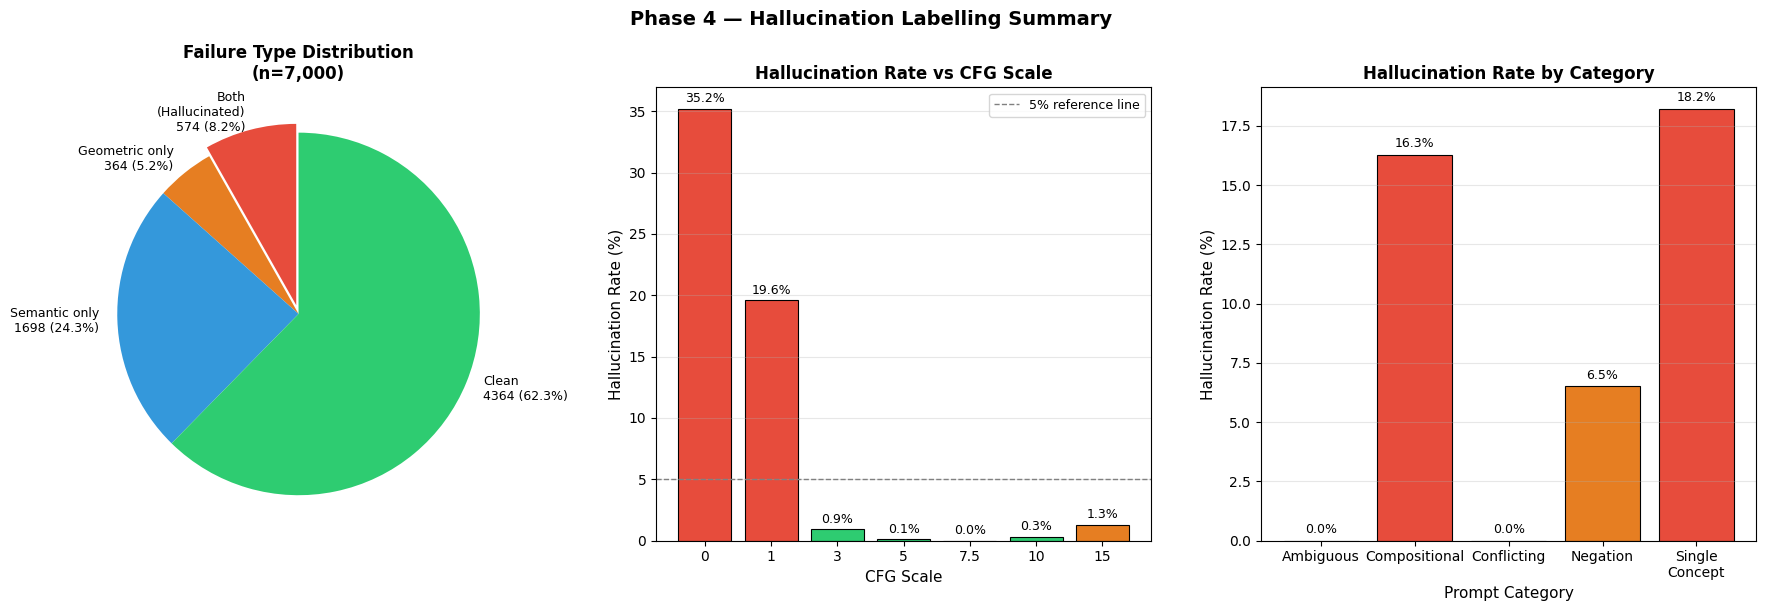


Figure saved: Phase4_Results\phase4_summary.png

Final record structure (1 sample):
{
    "key": "experimental__SC1__s000__cfg0.0",
    "split": "experimental",
    "prompt_id": "SC1",
    "category": "Single-Concept",
    "prompt": "A single red apple",
    "seed": 0,
    "cfg": 0,
    "variance": 0.003340875031426549,
    "clip_score": 0.132683,
    "yolo_error": true,
    "yolo_detail": "missing: apple not detected",
    "T_var": 0.00339307,
    "T_clip": 0.228177,
    "high_variance": false,
    "low_clip": true,
    "yolo_fail": true,
    "hallucinated": false,
    "failure_type": "semantic"
}

PHASE 4 COMPLETE

  Files saved to Phase4_Results/:
    baseline_with_clip.json                     264.5 KB
    experimental_with_clip.json                1896.6 KB
    experimental_with_yolo.json                2336.6 KB
    phase4_results.json                        3606.5 KB
    phase4_summary.png                          128.1 KB
    thresholds.json                               1.2 K

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("=" * 55)
print("SECTION 7 — SANITY CHECKS + SUMMARY")
print("=" * 55)

required_fields = [
    "key", "prompt_id", "category", "prompt", "seed", "cfg",
    "variance", "clip_score", "yolo_error", "yolo_detail",
    "high_variance", "low_clip", "yolo_fail",
    "hallucinated", "failure_type", "T_var", "T_clip"
]

missing_fields = []
for i, r in enumerate(phase4_results):
    for field in required_fields:
        if field not in r:
            missing_fields.append((i, field))

if missing_fields:
    print(f"Missing fields found: {missing_fields[:5]}")
else:
    print(f"Check 1: All {len(required_fields)} fields present in all "
          f"{len(phase4_results)} records")

inconsistent = []
for r in phase4_results:
    expected_hall = r["high_variance"] and (r["yolo_fail"] or r["low_clip"])
    if r["hallucinated"] != expected_hall:
        inconsistent.append(r["key"])

if inconsistent:
    print(f"Check 2: {len(inconsistent)} inconsistent labels")
else:
    print(f"Check 2: All hallucination labels are logically consistent")

type_errors = []
for r in phase4_results:
    hv = r["high_variance"]
    sf = r["yolo_fail"] or r["low_clip"]
    ft = r["failure_type"]
    expected_ft = (
        "both"      if hv and sf  else
        "geometric" if hv and not sf else
        "semantic"  if not hv and sf else
        "none"
    )
    if ft != expected_ft:
        type_errors.append(r["key"])

if type_errors:
    print(f"Check 3: {len(type_errors)} failure_type mismatches")
else:
    print(f"Check 3: All failure_type labels match flag combinations")

assert len(phase4_results) == 7000, "Expected 7000 records"
print(f"Check 4: Record count = {len(phase4_results)}")

print()
print("PHASE 4 FINAL SUMMARY")

cats = sorted(set(r["category"] for r in phase4_results))
cfgs = sorted(set(r["cfg"] for r in phase4_results))

hall_by_cat = {
    cat: sum(1 for r in phase4_results
             if r["category"] == cat and r["hallucinated"])
    for cat in cats
}
hall_by_cfg = {
    cfg: sum(1 for r in phase4_results
             if r["cfg"] == cfg and r["hallucinated"])
    for cfg in cfgs
}
total_by_cfg = {
    cfg: sum(1 for r in phase4_results if r["cfg"] == cfg)
    for cfg in cfgs
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Phase 4 — Hallucination Labelling Summary", fontsize=14,
             fontweight="bold", y=1.01)

ax = axes[0]
sizes  = [574, 364, 1698, 4364]
labels = ["Both\n(Hallucinated)\n574 (8.2%)",
          "Geometric only\n364 (5.2%)",
          "Semantic only\n1698 (24.3%)",
          "Clean\n4364 (62.3%)"]
colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71"]
explode = (0.05, 0, 0, 0)
wedges, texts = ax.pie(sizes, labels=labels, colors=colors,
                       explode=explode, startangle=90,
                       textprops={"fontsize": 9})
ax.set_title("Failure Type Distribution\n(n=7,000)", fontweight="bold")

ax = axes[1]
cfg_labels  = [str(c) for c in cfgs]
cfg_rates   = [100 * hall_by_cfg[c] / total_by_cfg[c] for c in cfgs]
bar_colors  = ["#e74c3c" if r > 5 else "#e67e22" if r > 1
               else "#2ecc71" for r in cfg_rates]
bars = ax.bar(cfg_labels, cfg_rates, color=bar_colors, edgecolor="black",
              linewidth=0.8)
ax.axhline(y=5, color="gray", linestyle="--", linewidth=1,
           label="5% reference line")
for bar, rate in zip(bars, cfg_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("CFG Scale", fontsize=11)
ax.set_ylabel("Hallucination Rate (%)", fontsize=11)
ax.set_title("Hallucination Rate vs CFG Scale", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
cat_rates = [100 * hall_by_cat[c] / 1400 for c in cats]
cat_short = [c.replace("-", "\n") for c in cats]
bar_colors2 = ["#e74c3c" if r > 10 else "#e67e22" if r > 3
               else "#2ecc71" for r in cat_rates]
bars2 = ax.bar(cat_short, cat_rates, color=bar_colors2, edgecolor="black",
               linewidth=0.8)
for bar, rate in zip(bars2, cat_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Prompt Category", fontsize=11)
ax.set_ylabel("Hallucination Rate (%)", fontsize=11)
ax.set_title("Hallucination Rate by Category", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = PHASE4_OUT / "phase4_summary.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved: {fig_path}")

print()
print("Final record structure (1 sample):")
print(json.dumps(phase4_results[0], indent=4))

print()
print("PHASE 4 COMPLETE")
print()
print("  Files saved to Phase4_Results/:")
for f in sorted(Path("Phase4_Results").glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"    {f.name:<40} {size_kb:>8.1f} KB")
print()
print("  Ready for Phase 5 — Statistical Analysis.")